## Libraries

In [2]:
# Libraries
import distribution_system
import bus_loads
import ev_loads

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from distribution_system import build_RX_matrices
from bus_loads import prepare_bus_loads
from ev_loads import prepare_ev_profile

plt.rcParams.update({
    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Fonts
    "font.size": 30,          # base font size
    "axes.titlesize": 30,     # title
    "axes.labelsize": 30,     # x,y labels

    # Tick labels
    "xtick.labelsize": 20,
    "ytick.labelsize": 30,

    # Tick direction (correct way)
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Legend
    "legend.fontsize": 30,
    "legend.frameon": False,

    # Lines
    "lines.linewidth": 2,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.3,

    # Better layout
    "figure.autolayout": True,

    "text.usetex": False,   # set True if LaTeX installed
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

## Dataset

- **Generating power system constraints**
- **Loading bus data**
- **Loading EV profiles**

In [4]:
# Generating R and X matrices for the IEEE 123 bus system, with bus 114 as the root bus

print("Loading line data and building R and X matrices...")
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)


# Loading bus load data from NREL dataset
print("Loading bus load data and preparing bus loads...")
S_base, bus_load_pu, bus_load_kw_final = prepare_bus_loads(
    file_path="dataset",
    line_df = line_df, 
    R = R, 
    X = X, 
    root_bus = 114, 
    seed = 0, 
    power_factor = 0.9
)

# Loading EV charging profile from Norway
print("Loading EV profile data and preparing EV profile...")
ev_df, lhat = prepare_ev_profile(file_path='EV/dataset_3a_aggregated.csv')

Loading line data and building R and X matrices...
Loading bus load data and preparing bus loads...
Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 389.4856114476723
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.8999999999999999
Minimum voltage after headroom scaling: 0.9516993402398705
Available headroom at peak (pu): 0.10000000000000009
Available headroom at peak (kW): 43.276179049741245
Loading EV profile data and preparing EV profile...
Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


c:\Users\gcsar\OneDrive\Desktop\project folder\dynamic_hosting\ev_loads.py:29: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


### Visualization

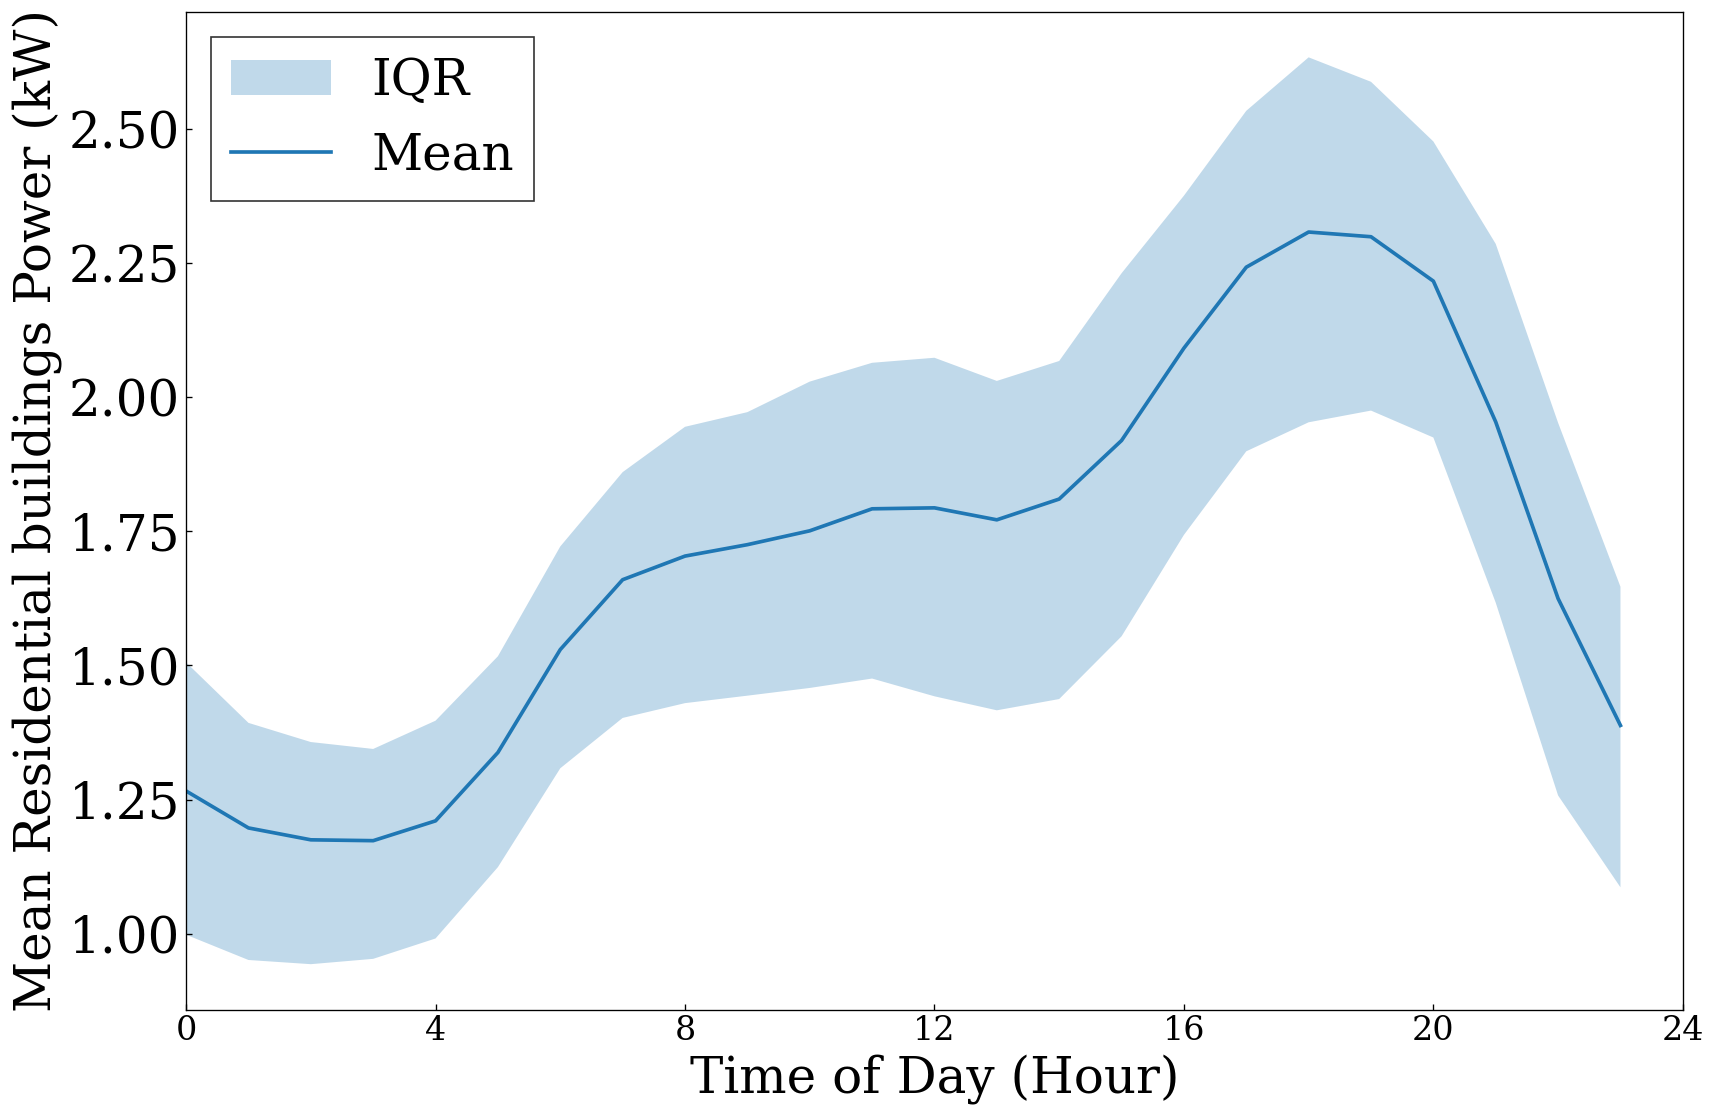

In [5]:
# Visualization

base_load = bus_load_kw_final.mean(axis=1)

def hourly_mean_iqr(series):
    df = pd.DataFrame({"value": series})
    df["hour"] = df.index.hour

    stats = df.groupby("hour")["value"].agg([
        ("q25", lambda x: np.percentile(x, 25)),
        ("mean", "mean"),
        ("q75", lambda x: np.percentile(x, 75)),
    ])
    return stats

res_stats = hourly_mean_iqr(base_load)

# Residential power plot
plt.figure(figsize=(15, 10))
h = res_stats.index.to_numpy()
m = res_stats["mean"].to_numpy()
q25 = res_stats["q25"].to_numpy()
q75 = res_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Mean Residential buildings Power (kW)", fontsize=30)
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


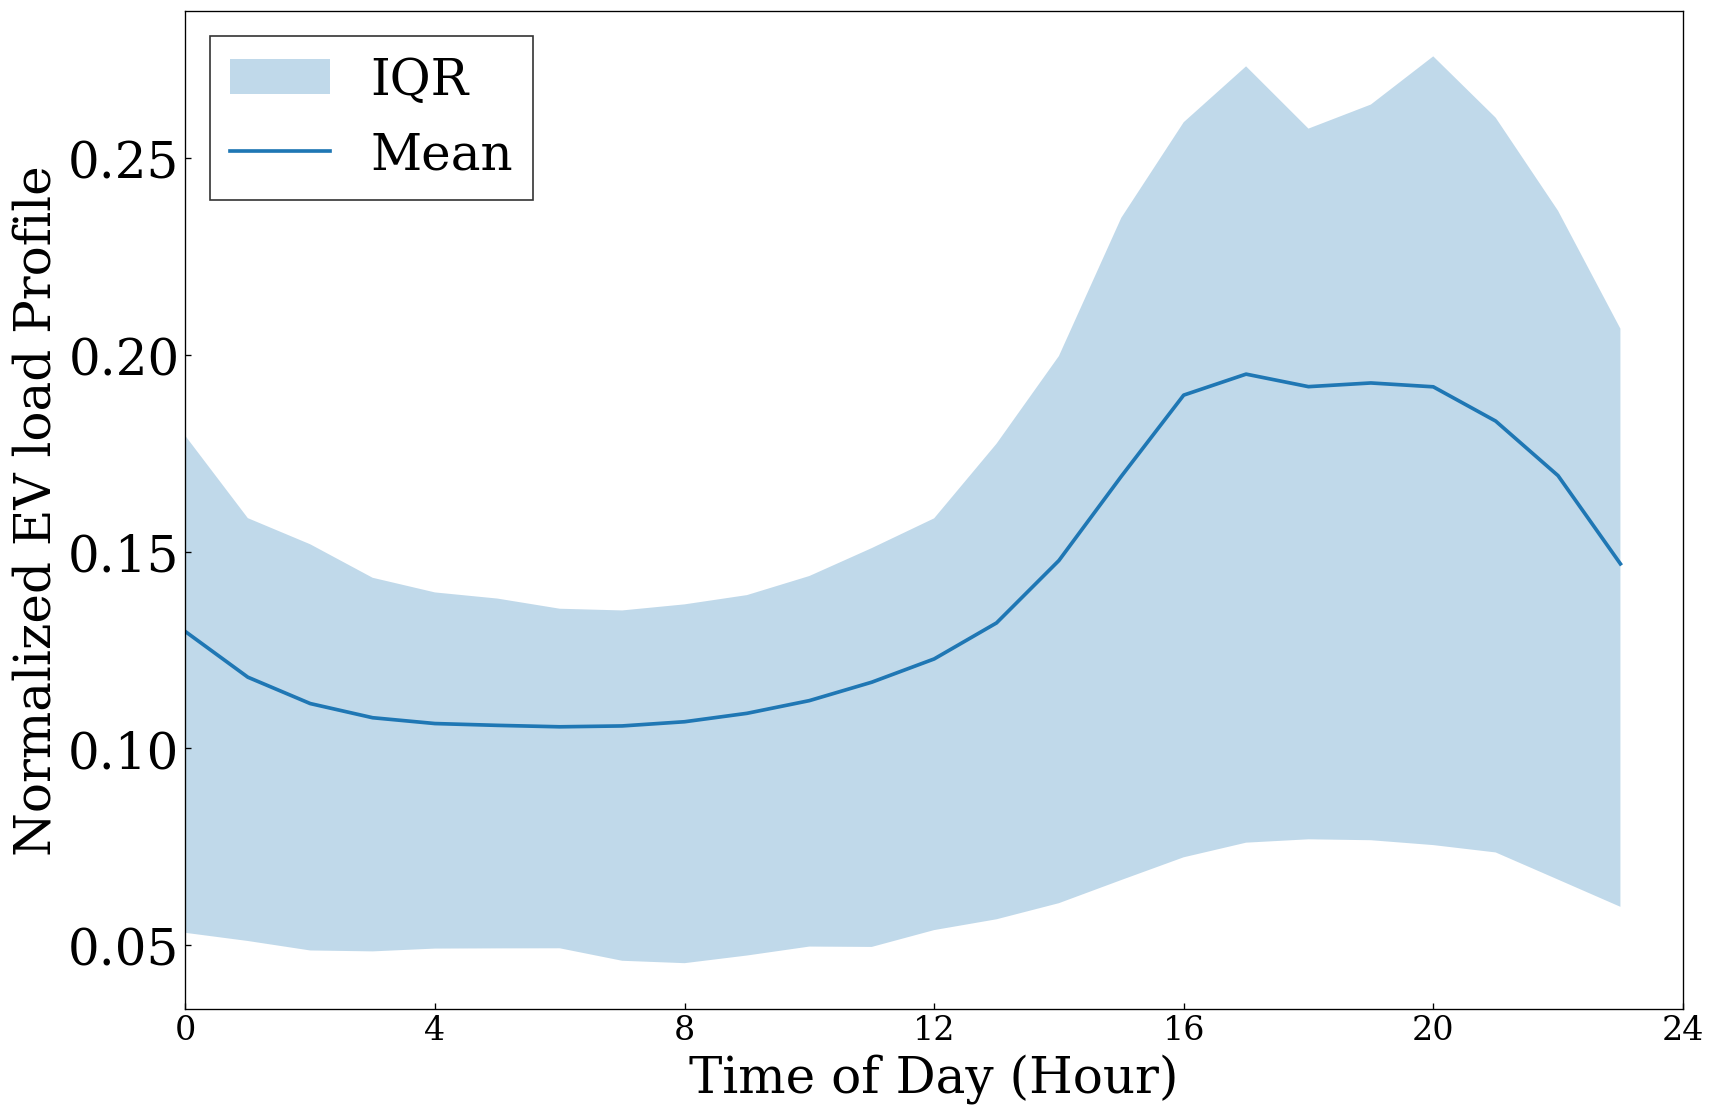

In [6]:
ev_df['Synthetic_7_2kW_normalized'] = ev_df['Synthetic_7_2kW']/ev_df['Synthetic_7_2kW'].max()

ev_stats = hourly_mean_iqr(ev_df['Synthetic_7_2kW_normalized']) 

# Residential power plot
plt.figure(figsize=(15, 10))
h = ev_stats.index.to_numpy()
m = ev_stats["mean"].to_numpy()
q25 = ev_stats["q25"].to_numpy()
q75 = ev_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Normalized EV load Profile")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


### Hosting Capacity

In [ ]:
def system_constraint(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    Del_P = np.full(T, np.inf, dtype=float)
    Del_P_dyn = np.full(T, np.inf, dtype=float)

    L = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - L[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        Del_P[t] = min(headroom_tx, headroom_v)
        # Del_P[t] = headroom_tx   # for copperplate

        if lhat_new[t] > 1e-12:
            Del_P_dyn[t] = Del_P[t] / lhat_new[t]
        else:
            Del_P_dyn[t] = np.inf

    return Del_P, Del_P_dyn

In [12]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

NameError: name 'ev_df' is not defined

### Optimization

In [15]:
def optimization(Del_P, lhat, alpha=0.95, rho=0.10, lam=1e-4,
                 C_max=1.0, solver="GUROBI", verbose=True):
    T = len(Del_P)

    P = cp.Variable(nonneg=True, name="C")
    p_curt = cp.Variable(T, nonneg=True, name="u")
    gamma = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    Del_P_pos = np.maximum(Del_P, 0.0)
    w = Del_P_pos + 1e-3
    w = w / max(np.max(w), 1e-8)


    constraints = [
        P * lhat - p_curt <= Del_P,
        s >= p_curt - rho * P * lhat - gamma,
        gamma + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0
    ]

    if C_max is not None:
        constraints += [P <= C_max]

    obj = cp.Maximize(P - lam * cp.sum(cp.multiply(w, p_curt)))
    # obj = cp.Maximize(P)
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=solver, verbose=verbose)

    return {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "P": None if P.value is None else float(P.value),
        "gamma": None if gamma.value is None else float(gamma.value),
        "p_curt": None if p_curt.value is None else np.asarray(p_curt.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
        "w": w,
    }


In [16]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

Del_P, Del_P_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95

# N_int = 350
# alpha = 1 - N_int/T  
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
rho = 0.1       # max 10% curtailment per timestamp

res = optimization(
    Del_P=Del_P,
    lhat=lhat,
    alpha=alpha,
    rho=rho,
    solver="CLARABEL",
    verbose=False,
    lam = 0
)

print("Status:", res["status"])
print("Optimal P:", res["P"])
print("Optimal P in kW:", None if res["P"] is None else res["P"] * S_base)
print("gamma:", res["gamma"])

Status: optimal
Optimal P: 0.538862378215243
Optimal P in kW: 233.199047628123
gamma: -0.0010745957848831015


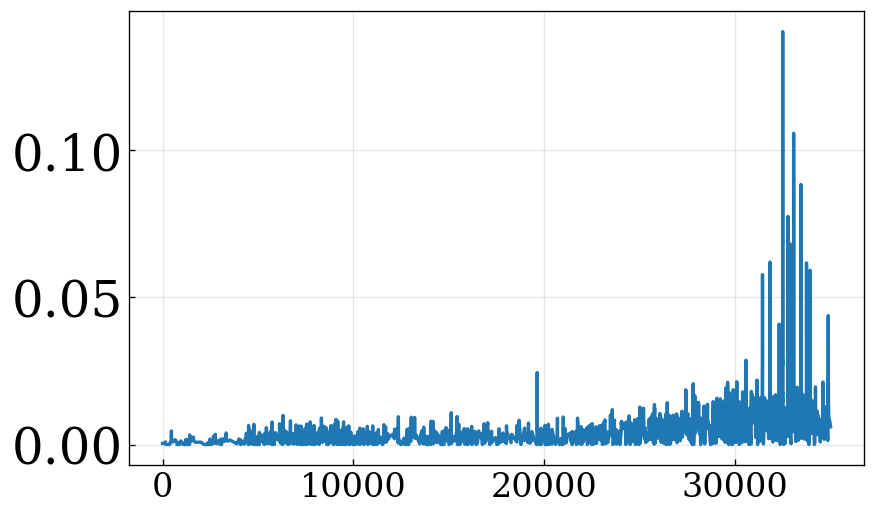

In [17]:
plt.plot(res["p_curt"])

In [18]:
def tune_lambda_for_intervention(
    Del_P,
    lhat,
    N_int,
    alpha=0.95,
    rho=0.1,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol=5,
    solver="CLARABEL",
    patience = 5
):
    T = len(Del_P)
    tol = 1e-6

    best_res = None
    last_intervention_count = None
    stagnant_counter = 0

    for i in range(max_iter):
        lam_mid = 0.5 * (lam_low + lam_high)

        res = optimization(
            Del_P=Del_P,
            lhat=lhat,
            alpha=alpha,
            rho=rho,
            lam=lam_mid,
            solver=solver,
            verbose=False
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"]:
            print("Solver failed at iteration", i)
            break

        p_curt = res["p_curt"]
        N_actual = np.sum(p_curt > tol)

        print(f"Iter {i}: lam={lam_mid:.4e}, N_actual={N_actual}, P={res['P']*S_base:.2f} kW")

        # Store best
        best_res = res

        # early stopping if N_int is not improving
        if last_intervention_count is not None and N_actual == last_intervention_count:
            stagnant_counter += 1
        else:
            stagnant_counter = 0

        last_intervention_count = N_actual

        if stagnant_counter >= patience:
            print(f"Early stopping: N_actual unchanged for {patience} iterations")
            break

        # Check convergence
        if abs(N_actual - N_int) <= tol:
            
            print("Converged!")
            break

        # Bisection update
        if N_actual > N_int:
            lam_low = lam_mid   # need fewer interventions → increase λ
        else:
            lam_high = lam_mid  # need more interventions → decrease λ

    return best_res, lam_mid

In [19]:
best_res, best_lambda = tune_lambda_for_intervention(
    Del_P=Del_P,
    lhat=lhat,
    N_int=350,
    alpha=0.95,
    rho=0.1,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol=5, # patience for early stopping based on N_actual not changing
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, N_actual=9, P=179.85 kW
Iter 1: lam=2.5000e-01, N_actual=18, P=188.29 kW
Iter 2: lam=1.2500e-01, N_actual=34, P=206.24 kW
Iter 3: lam=6.2501e-02, N_actual=62, P=223.01 kW
Iter 4: lam=3.1251e-02, N_actual=74, P=233.20 kW
Iter 5: lam=1.5626e-02, N_actual=74, P=233.20 kW
Iter 6: lam=7.8135e-03, N_actual=74, P=233.20 kW
Iter 7: lam=3.9072e-03, N_actual=74, P=233.20 kW
Iter 8: lam=1.9541e-03, N_actual=74, P=233.20 kW
Iter 9: lam=9.7756e-04, N_actual=74, P=233.20 kW
Early stopping: N_actual unchanged for 5 iterations


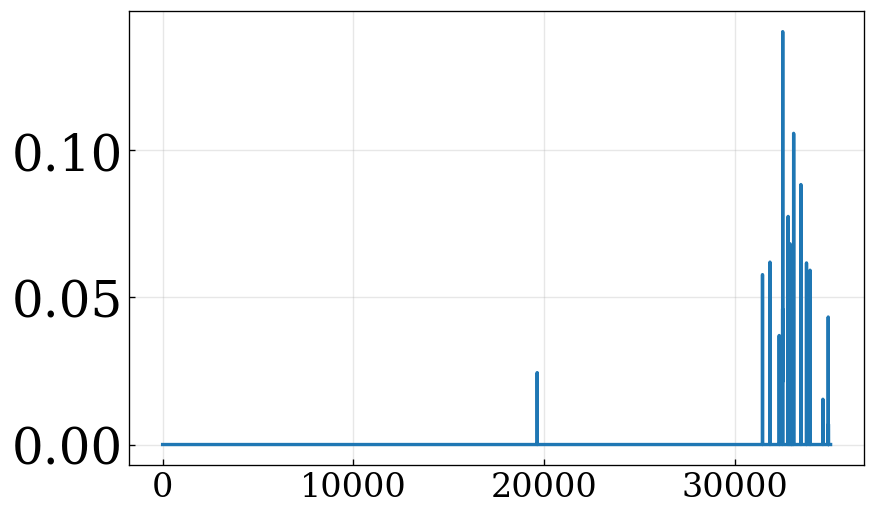

In [20]:
plt.plot(best_res["p_curt"])

### Hosting capacity vs. Intervention Count

In [21]:
# ===== Baseline (no curtailment) =====
tol = 1e-9
mask = lhat > tol
P_base = np.min(Del_P[mask] / lhat[mask])
P_base_kw = P_base * S_base

print(f"Baseline capacity = {P_base_kw:.2f} kW")

# ===== Setup =====
N_int_vals = [0, 50, 100, 150, 200, 250, 300, 350]
rho_list = [0.0, 0.05, 0.10, 0.15, 0.20]

results_N_int = {}

for rho in rho_list:
    gain_vals = []

    print(f"\n===== Running for rho = {rho} =====")

    for N_int in N_int_vals:
        if N_int == 0:
            gain_vals.append(0.0)
            print(f"N_int={N_int}, gain=0%")
            continue

        best_res, lam_opt = tune_lambda_for_intervention(
            Del_P=Del_P,
            lhat=lhat,
            N_int=N_int,
            alpha=0.95,
            rho=rho,
            lam_low=1e-6,
            lam_high=1.0,
            max_iter=30,
            tol=5,
            solver="CLARABEL",
            patience=5
        )

        if best_res is None or best_res["status"] not in ["optimal", "optimal_inaccurate"]:
            gain_vals.append(np.nan)
            print(f"N_int={N_int}, status=failed")
        else:
            P_kw = best_res["P"] * S_base
            gain_pct = 100.0 * (P_kw - P_base_kw) / P_base_kw
            gain_vals.append(gain_pct)

            N_actual = np.sum(best_res["p_curt"] > 1e-6)
            print(
                f"N_int={N_int}, "
                f"N_actual={N_actual}, "
                f"gain={gain_pct:.2f}%"
            )

    results_N_int[rho] = np.array(gain_vals)


Baseline capacity = 162.72 kW

===== Running for rho = 0.0 =====
N_int=0, gain=0%
Iter 0: lam=5.0000e-01, N_actual=0, P=162.72 kW
Iter 1: lam=2.5000e-01, N_actual=0, P=162.72 kW
Iter 2: lam=1.2500e-01, N_actual=0, P=162.72 kW
Iter 3: lam=6.2501e-02, N_actual=0, P=162.72 kW
Iter 4: lam=3.1251e-02, N_actual=0, P=162.72 kW
Iter 5: lam=1.5626e-02, N_actual=0, P=162.72 kW
Early stopping: N_actual unchanged for 5 iterations
N_int=50, N_actual=0, gain=0.00%
Iter 0: lam=5.0000e-01, N_actual=0, P=162.72 kW
Iter 1: lam=2.5000e-01, N_actual=0, P=162.72 kW
Iter 2: lam=1.2500e-01, N_actual=0, P=162.72 kW
Iter 3: lam=6.2501e-02, N_actual=0, P=162.72 kW
Iter 4: lam=3.1251e-02, N_actual=0, P=162.72 kW
Iter 5: lam=1.5626e-02, N_actual=0, P=162.72 kW
Early stopping: N_actual unchanged for 5 iterations
N_int=100, N_actual=0, gain=0.00%
Iter 0: lam=5.0000e-01, N_actual=0, P=162.72 kW
Iter 1: lam=2.5000e-01, N_actual=0, P=162.72 kW
Iter 2: lam=1.2500e-01, N_actual=0, P=162.72 kW
Iter 3: lam=6.2501e-02, N_a

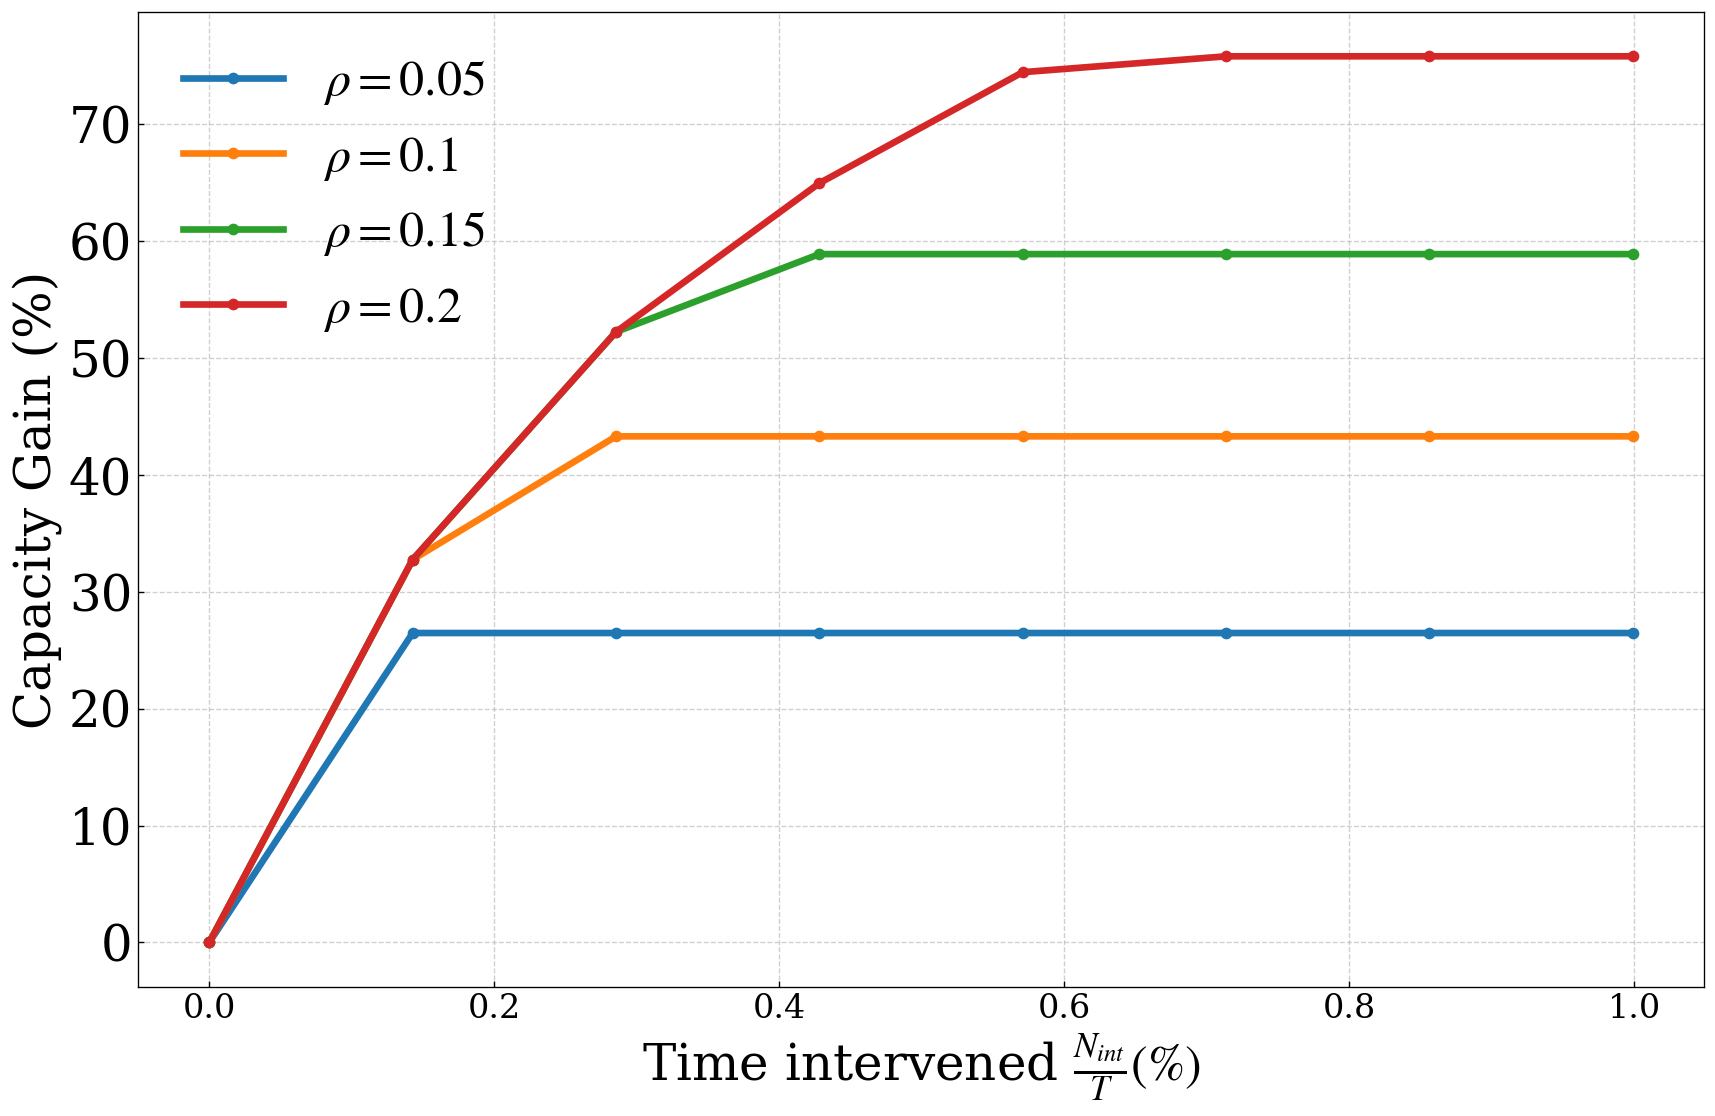

In [22]:
plt.figure(figsize=(15, 10))

for rho in rho_list[1:]:
    plt.plot(
        np.array(N_int_vals)/T*100,   # convert to percentage of time steps
        results_N_int[rho],
        marker='o',
        linewidth=4,
        label=fr'$\rho = {rho}$'
    )

plt.xlabel(r'Time intervened $\frac{N_{int}}{T} (\%)$')
plt.ylabel('Capacity Gain (%)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Time intervened Vs Regularization (lambda)

In [27]:
def lambda_vs_intervention_budget(
    Del_P,
    lhat,
    alpha=0.95,
    rho=0.10,
    lam_vals=None,
    solver="CLARABEL",
    tol=1e-6,
):
    if lam_vals is None:
        lam_vals = np.logspace(-2, 2, 20)

    N_vals = []
    P_vals = []
    gamma_vals = []
    status_vals = []

    for lam in lam_vals:
        res = optimization(
            Del_P=Del_P,
            lhat=lhat,
            alpha=alpha,
            rho=rho,
            lam=lam,
            solver=solver,
            verbose=False
        )

        status_vals.append(res["status"])

        if res["status"] not in ["optimal", "optimal_inaccurate"] or res["p_curt"] is None:
            N_vals.append(np.nan)
            P_vals.append(np.nan)
            gamma_vals.append(np.nan)
            print(f"lambda={lam:.3e}, status={res['status']}, N=nan")
            continue

        p_curt = np.asarray(res["p_curt"]).flatten()
        N_actual = np.sum(p_curt > tol)

        N_vals.append(N_actual)
        P_vals.append(res["P"])
        gamma_vals.append(res["gamma"])

        print(
            f"lambda={lam:.3e}, "
            f"status={res['status']}, "
            f"N_actual={N_actual}, "
            f"P={res['P']:.4f}, "
            f"gamma={res['gamma']:.4f}"
        )

    return {
        "lam_vals": np.array(lam_vals),
        "N_vals": np.array(N_vals),
        "P_vals": np.array(P_vals),
        "gamma_vals": np.array(gamma_vals),
        "status_vals": status_vals,
    }



In [28]:
rho_list = [0.05, 0.10, 0.15, 0.20]
lam_vals = np.logspace(-2, 0, 10)

all_results = {}

for rho in rho_list:
    print(f"\n===== Running for rho = {rho} =====")
    
    res_lam = lambda_vs_intervention_budget(
        Del_P=Del_P,
        lhat=lhat,
        alpha=0.95,
        rho=rho,
        lam_vals=lam_vals,
        solver="CLARABEL",
        tol=1e-6,
    )
    
    all_results[rho] = res_lam


===== Running for rho = 0.05 =====
lambda=1.000e-02, status=optimal, N_actual=34, P=0.4756, gamma=-0.0005
lambda=1.668e-02, status=optimal, N_actual=34, P=0.4756, gamma=-0.0005
lambda=2.783e-02, status=optimal, N_actual=34, P=0.4756, gamma=-0.0005
lambda=4.642e-02, status=optimal, N_actual=34, P=0.4756, gamma=-0.0005
lambda=7.743e-02, status=optimal, N_actual=34, P=0.4756, gamma=-0.0005
lambda=1.292e-01, status=optimal, N_actual=32, P=0.4716, gamma=-0.0005
lambda=2.154e-01, status=optimal, N_actual=20, P=0.4417, gamma=-0.0004
lambda=3.594e-01, status=optimal, N_actual=13, P=0.4218, gamma=-0.0004
lambda=5.995e-01, status=optimal, N_actual=7, P=0.4097, gamma=-0.0004
lambda=1.000e+00, status=optimal, N_actual=5, P=0.4032, gamma=-0.0004

===== Running for rho = 0.1 =====
lambda=1.000e-02, status=optimal, N_actual=74, P=0.5389, gamma=-0.0011
lambda=1.668e-02, status=optimal, N_actual=74, P=0.5389, gamma=-0.0011
lambda=2.783e-02, status=optimal, N_actual=74, P=0.5389, gamma=-0.0011
lambda=4

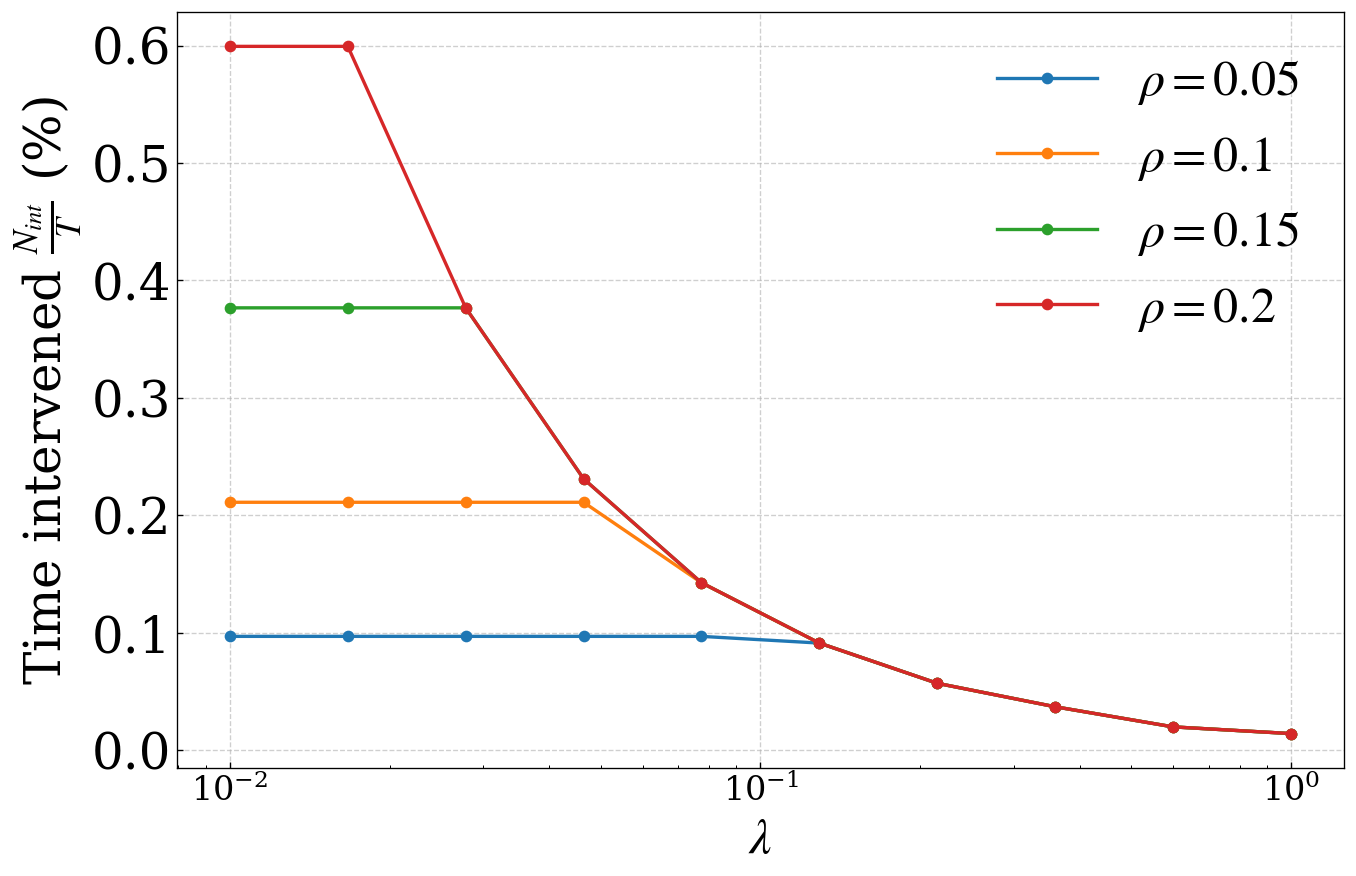

In [30]:
plt.figure(figsize=(12, 8))

for rho in rho_list:
    res = all_results[rho]
    
    T = len(Del_P)
    
    Int_percent = (np.array(res["N_vals"]) / T) * 100 #Percentage of time steps intervened
    
    plt.plot(
        res["lam_vals"],
        Int_percent,
        marker='o',
        linewidth=2,
        label=rf'$\rho = {rho}$'
    )

# Optional (recommended for lambda)
plt.xscale('log')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'Time intervened $\frac{N_{int}}{T}$ (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Hosting capacity vs confidence level

In [31]:
alpha_vals = np.linspace(0.8, 0.99, 12)
rho_list = [0.05, 0.10, 0.15, 0.20]

results_kw = {}

tol = 1e-9
mask = lhat > tol
P_base = np.min(Del_P[mask] / lhat[mask])     # per-unit capacity
P_base_kw = P_base * S_base

print(f"No-flexibility baseline capacity = {P_base:.4f} p.u. = {P_base_kw:.2f} kW")


for rho in rho_list:
    gain_vals = []

    print(f"\n===== Running for rho = {rho} =====")

    for alpha in alpha_vals:
        res = optimization(
            Del_P=Del_P,
            lhat=lhat,
            alpha=alpha,
            rho=rho,
            solver="CLARABEL",
            verbose=False,
            lam=1e-4
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"] or res["P"] is None:
            gain_vals.append(np.nan)
            print(f"alpha={alpha:.2f}, status={res['status']}, gain=nan")
        else:
            P_kw = res["P"] * S_base
            gain_pct = 100.0 * (P_kw - P_base_kw) / P_base_kw
            gain_vals.append(gain_pct)

            print(
                f"alpha={alpha:.2f}, "
                f"P*={P_kw:.2f} kW, "
                f"gain={gain_pct:.2f}%"
            )

    results_kw[rho] = np.array(gain_vals)



No-flexibility baseline capacity = 0.3760 p.u. = 162.72 kW

===== Running for rho = 0.05 =====
alpha=0.80, P*=267.31 kW, gain=64.27%
alpha=0.82, P*=260.99 kW, gain=60.39%
alpha=0.83, P*=254.51 kW, gain=56.40%
alpha=0.85, P*=247.80 kW, gain=52.28%
alpha=0.87, P*=240.97 kW, gain=48.09%
alpha=0.89, P*=234.42 kW, gain=44.06%
alpha=0.90, P*=227.94 kW, gain=40.08%
alpha=0.92, P*=220.80 kW, gain=35.69%
alpha=0.94, P*=212.62 kW, gain=30.66%
alpha=0.96, P*=202.93 kW, gain=24.71%
alpha=0.97, P*=193.57 kW, gain=18.96%
alpha=0.99, P*=179.48 kW, gain=10.30%

===== Running for rho = 0.1 =====
alpha=0.80, P*=320.66 kW, gain=97.06%
alpha=0.82, P*=312.04 kW, gain=91.76%
alpha=0.83, P*=302.90 kW, gain=86.14%
alpha=0.85, P*=293.54 kW, gain=80.39%
alpha=0.87, P*=284.27 kW, gain=74.70%
alpha=0.89, P*=274.35 kW, gain=68.60%
alpha=0.90, P*=263.72 kW, gain=62.06%
alpha=0.92, P*=252.43 kW, gain=55.12%
alpha=0.94, P*=241.36 kW, gain=48.32%
alpha=0.96, P*=229.12 kW, gain=40.80%
alpha=0.97, P*=213.72 kW, gain=31.

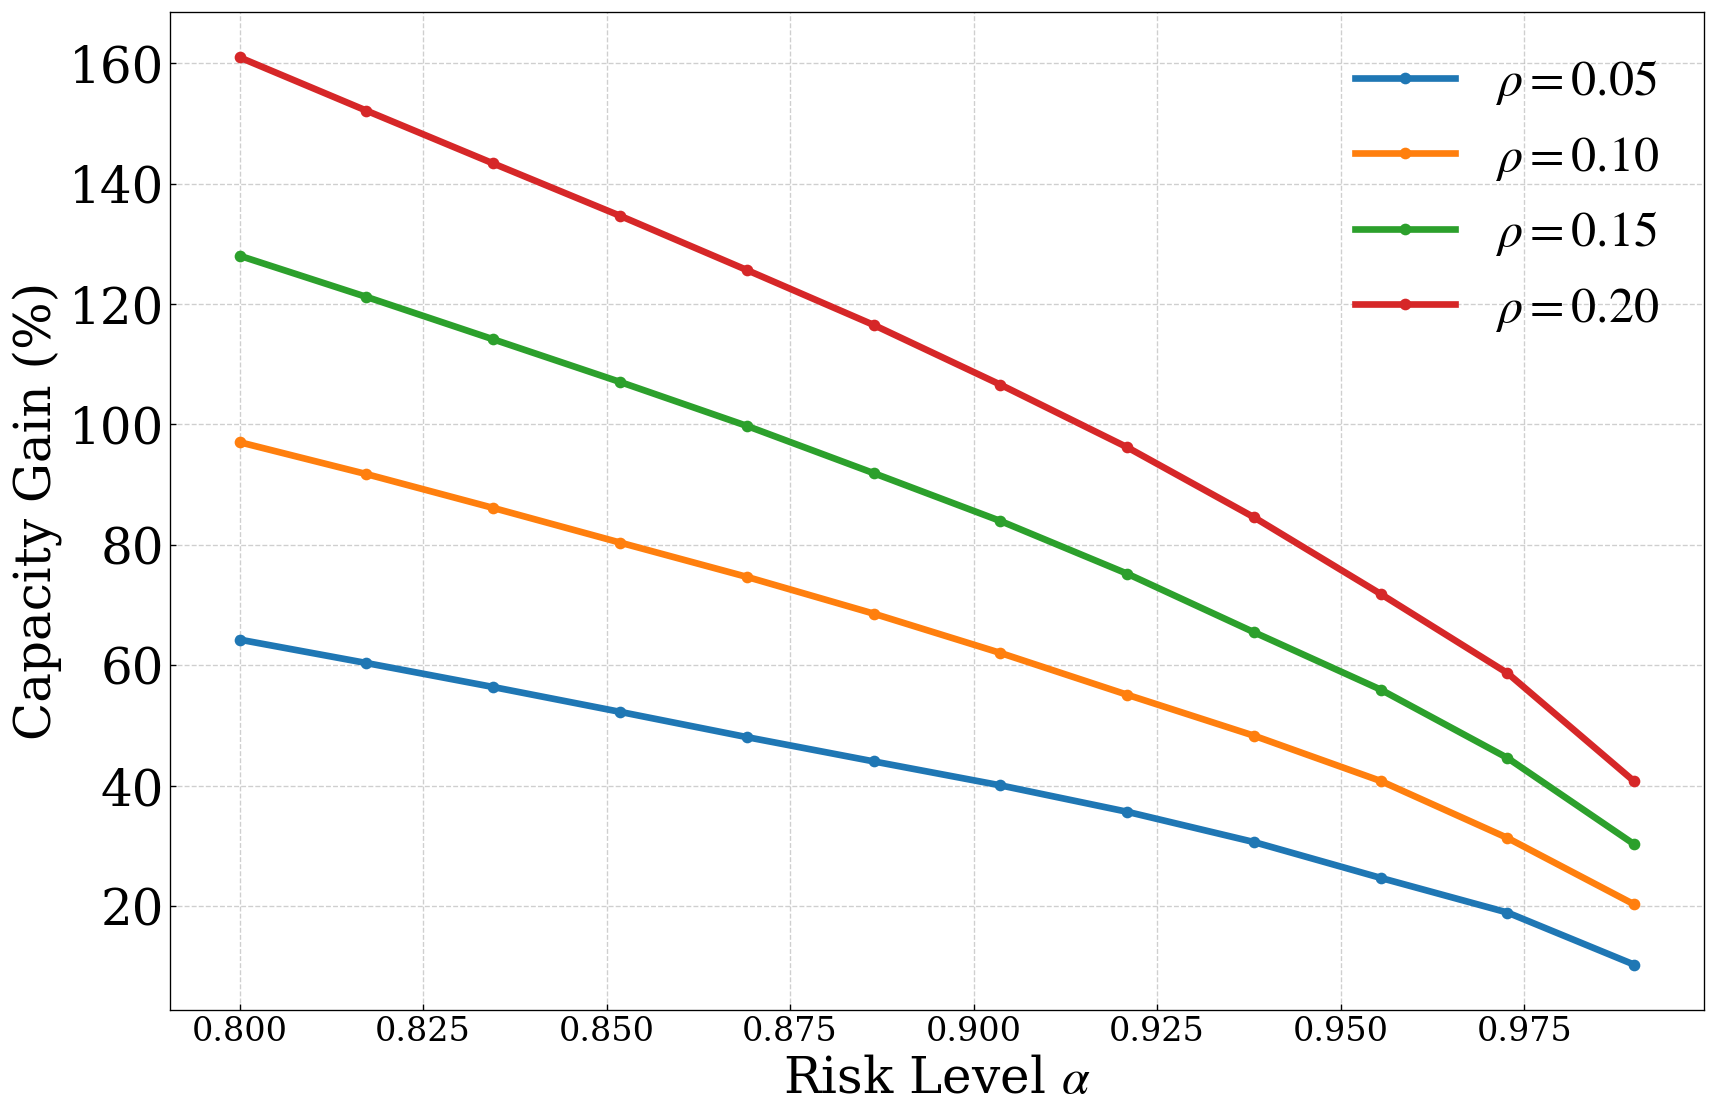

In [34]:
plt.figure(figsize=(15, 10))

for rho in rho_list:
    plt.plot(
        alpha_vals,
        results_kw[rho],
        marker='o',
        linewidth=4,
        label=fr'$\rho={rho:.2f}$'
    )

plt.xlabel(r'Risk Level $\alpha$')
plt.ylabel('Capacity Gain (%)')
# plt.title('Capacity Gain vs Risk Level for Different Curtailment Limits', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Load curtailment plot

In [33]:
best_res, best_lambda = tune_lambda_for_intervention(
    Del_P=Del_P,
    lhat=lhat,
    N_int=350,
    alpha=0.95,
    rho=0.2,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, N_actual=9, P=179.85 kW
Iter 1: lam=2.5000e-01, N_actual=18, P=188.29 kW
Iter 2: lam=1.2500e-01, N_actual=34, P=206.24 kW
Iter 3: lam=6.2501e-02, N_actual=62, P=223.01 kW
Iter 4: lam=3.1251e-02, N_actual=117, P=254.97 kW
Iter 5: lam=1.5626e-02, N_actual=210, P=286.12 kW
Iter 6: lam=7.8135e-03, N_actual=210, P=286.12 kW
Iter 7: lam=3.9072e-03, N_actual=210, P=286.12 kW
Iter 8: lam=1.9541e-03, N_actual=210, P=286.12 kW
Iter 9: lam=9.7756e-04, N_actual=210, P=286.12 kW
Iter 10: lam=4.8928e-04, N_actual=210, P=286.12 kW
Early stopping: N_actual unchanged for 5 iterations


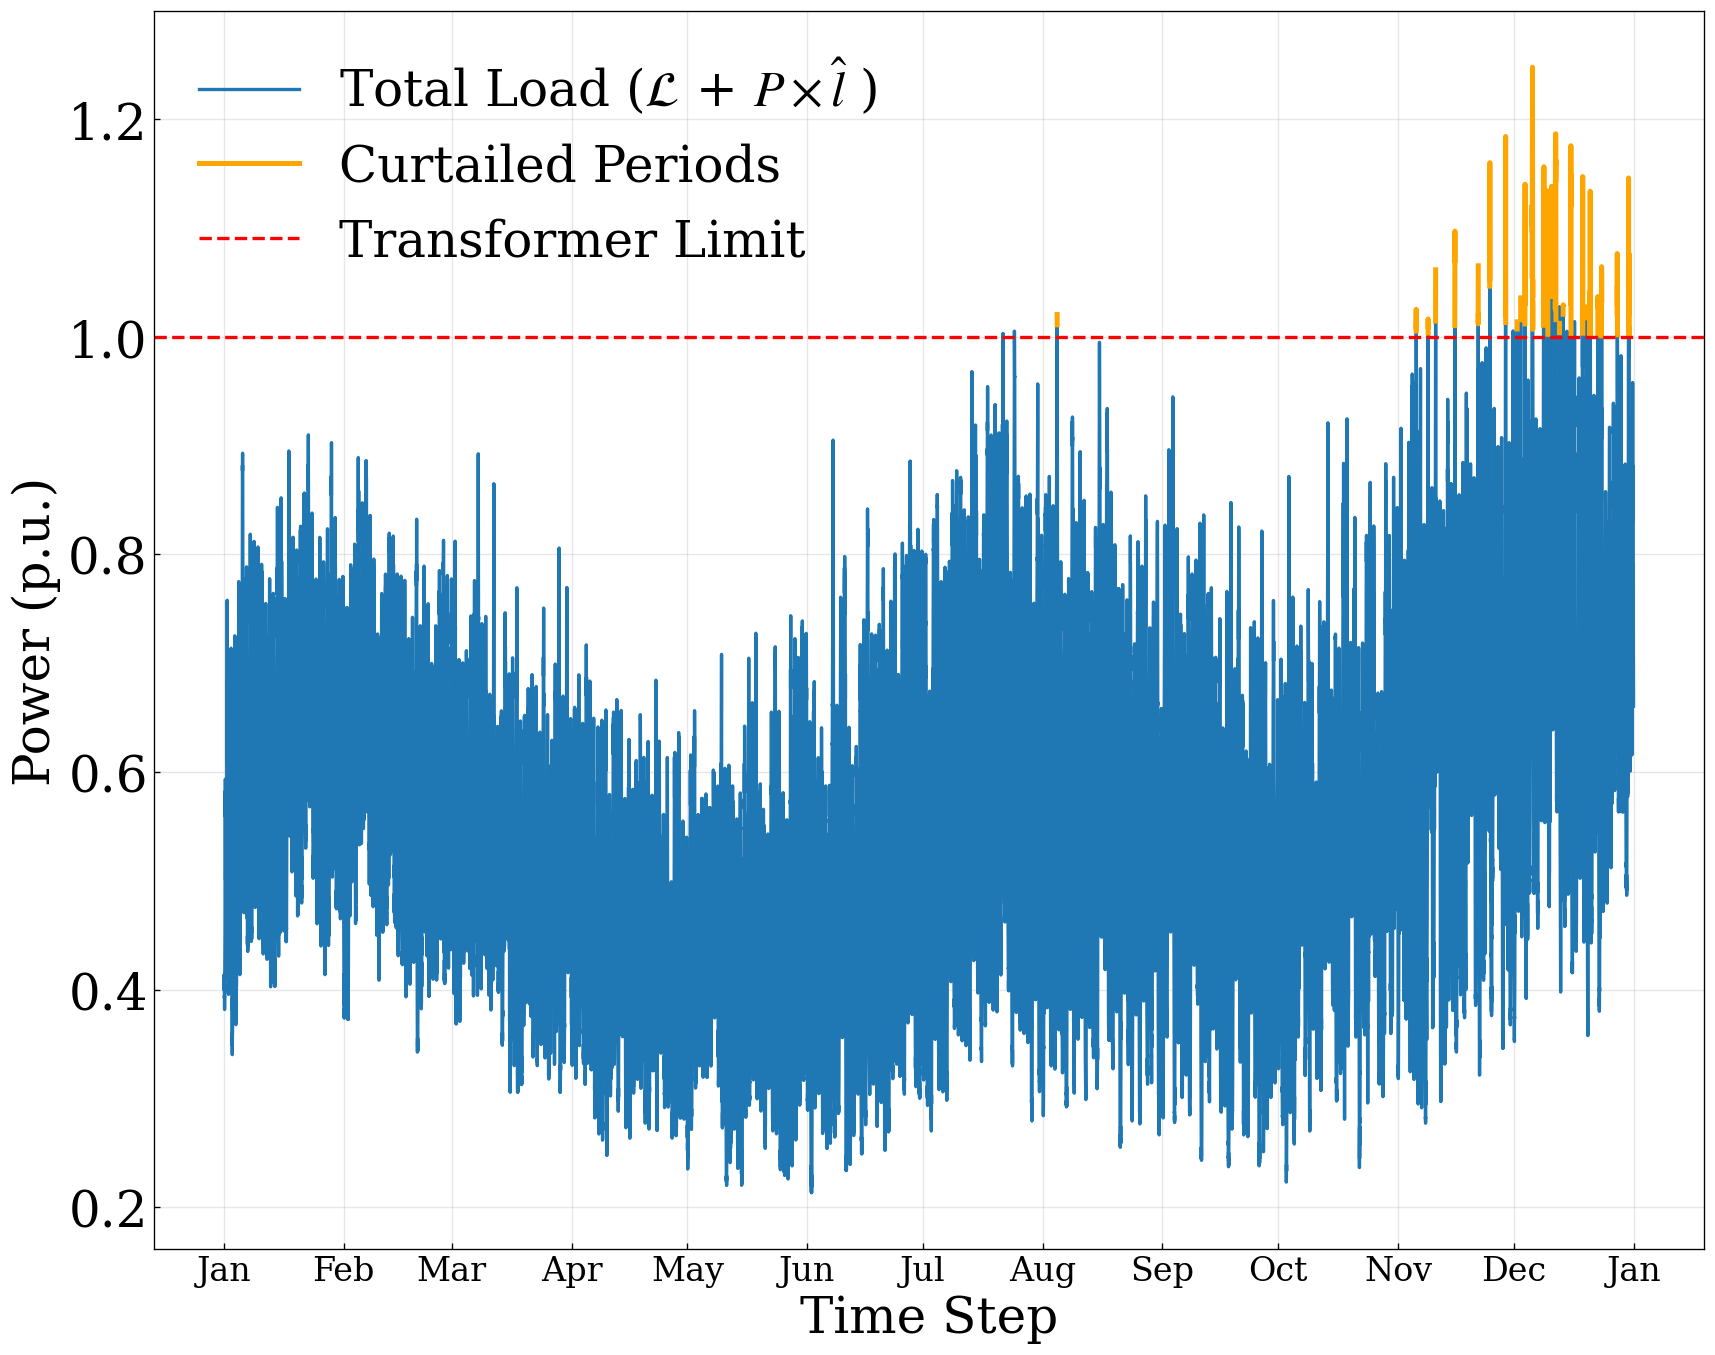

In [35]:
# Total Aggregated load
total_load = np.asarray(bus_load_pu.sum(axis=1) + best_res["P"] * lhat).flatten()

# curtailment profile
p_curt = np.asarray(best_res["p_curt"]).flatten()
tol = 1e-6
curt_idx = p_curt > tol

curt_load = np.full(total_load.shape, np.nan)
curt_load[curt_idx] = total_load[curt_idx]

limit = 1.0

# Time index for our data
time_index = pd.date_range(
    start="2007-01-01",
    end="2008-01-01",
    freq="15min",
    inclusive="left"
)

# Optional safety check
assert len(time_index) == len(total_load), f"{len(time_index)=}, {len(total_load)=}"


fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(
    time_index,
    total_load,
    linewidth=2,
    label=r"Total Load ($\mathcal{L}$ + $P \times \hat{l}$ )"
)
ax.plot(
    time_index,
    curt_load,
    linewidth=3,
    color="orange",
    label="Curtailed Periods"
)
ax.axhline(
    limit,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Transformer Limit"
)


ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_xlabel("Time Step")
ax.set_ylabel("Power (p.u.)")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

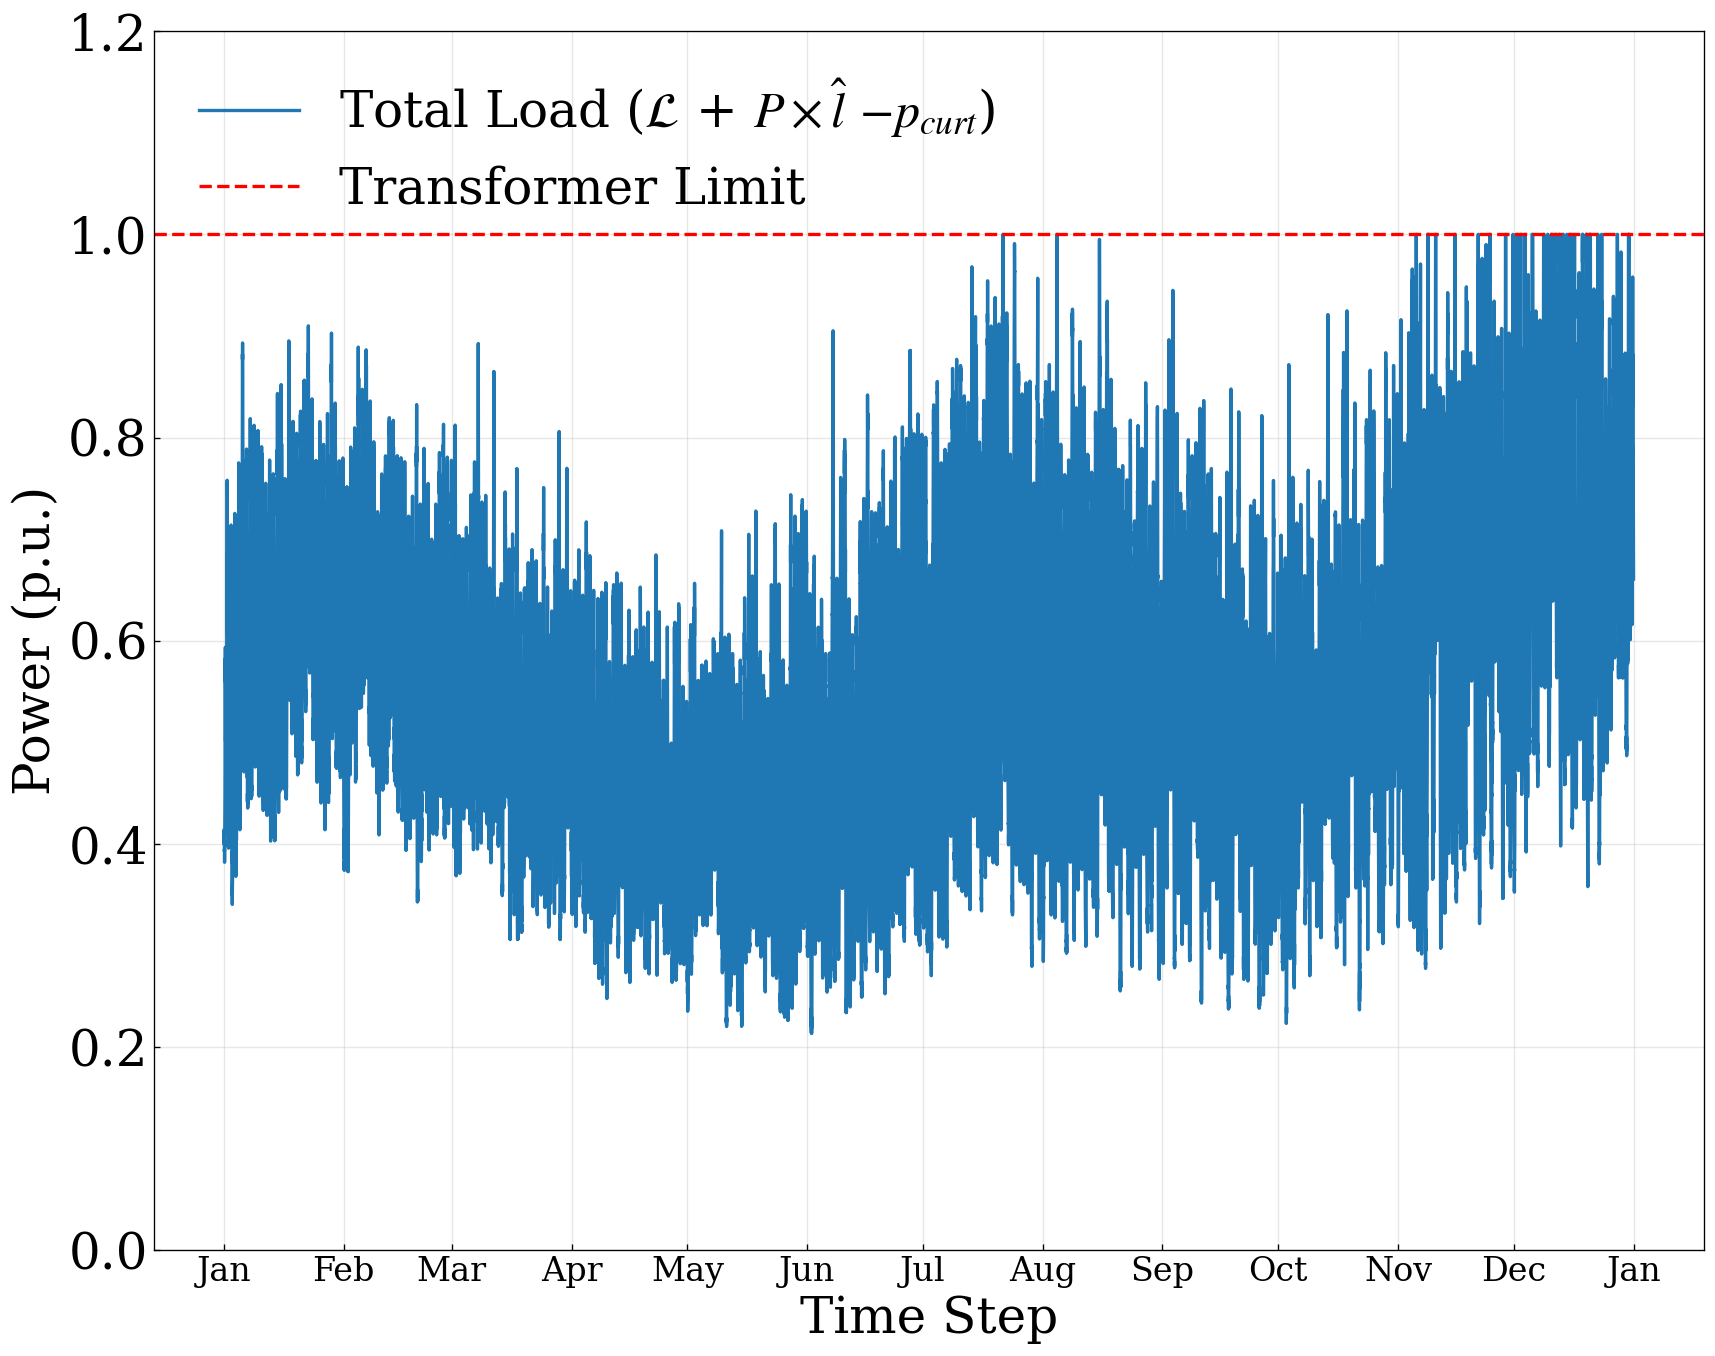

In [36]:
# Total load after curtailment
total_load = np.asarray(
    bus_load_pu.sum(axis=1) + best_res["P"] * lhat - best_res["p_curt"]
).flatten()

limit = 1.0

# ===== Time index =====
time_index = pd.date_range(
    start="2007-01-01",
    end="2008-01-01",
    freq="15min",
    inclusive="left"
)

# Safety check
assert len(time_index) == len(total_load), f"{len(time_index)=}, {len(total_load)=}"


fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(
    time_index,
    total_load,
    linewidth=2,
    label=r"Total Load ($\mathcal{L}$ + $P \times \hat{l}$ $- p_{curt}$)"
)

ax.axhline(
    limit,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Transformer Limit"
)

# ===== Month ticks =====
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_xlabel("Time Step")
ax.set_ylabel("Power (p.u.)")
ax.set_ylim(0, 1.2)

ax.legend(loc = "upper left")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### CVAR Tail

In [37]:
T = len(Del_P)
k_target = 350
alpha = 1 - k_target/T
rho = 0.2

best_res, best_lambda = tune_lambda_for_intervention(
    Del_P=Del_P,
    lhat=lhat,
    N_int=350,
    alpha=alpha,
    rho=rho,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, N_actual=9, P=179.85 kW
Iter 1: lam=2.5000e-01, N_actual=18, P=188.29 kW
Iter 2: lam=1.2500e-01, N_actual=34, P=206.24 kW
Iter 3: lam=6.2501e-02, N_actual=62, P=223.01 kW
Iter 4: lam=3.1251e-02, N_actual=69, P=228.98 kW
Iter 5: lam=1.5626e-02, N_actual=69, P=228.98 kW
Iter 6: lam=7.8135e-03, N_actual=69, P=228.98 kW
Iter 7: lam=3.9072e-03, N_actual=69, P=228.98 kW
Iter 8: lam=1.9541e-03, N_actual=69, P=228.98 kW
Iter 9: lam=9.7756e-04, N_actual=69, P=228.98 kW
Early stopping: N_actual unchanged for 5 iterations


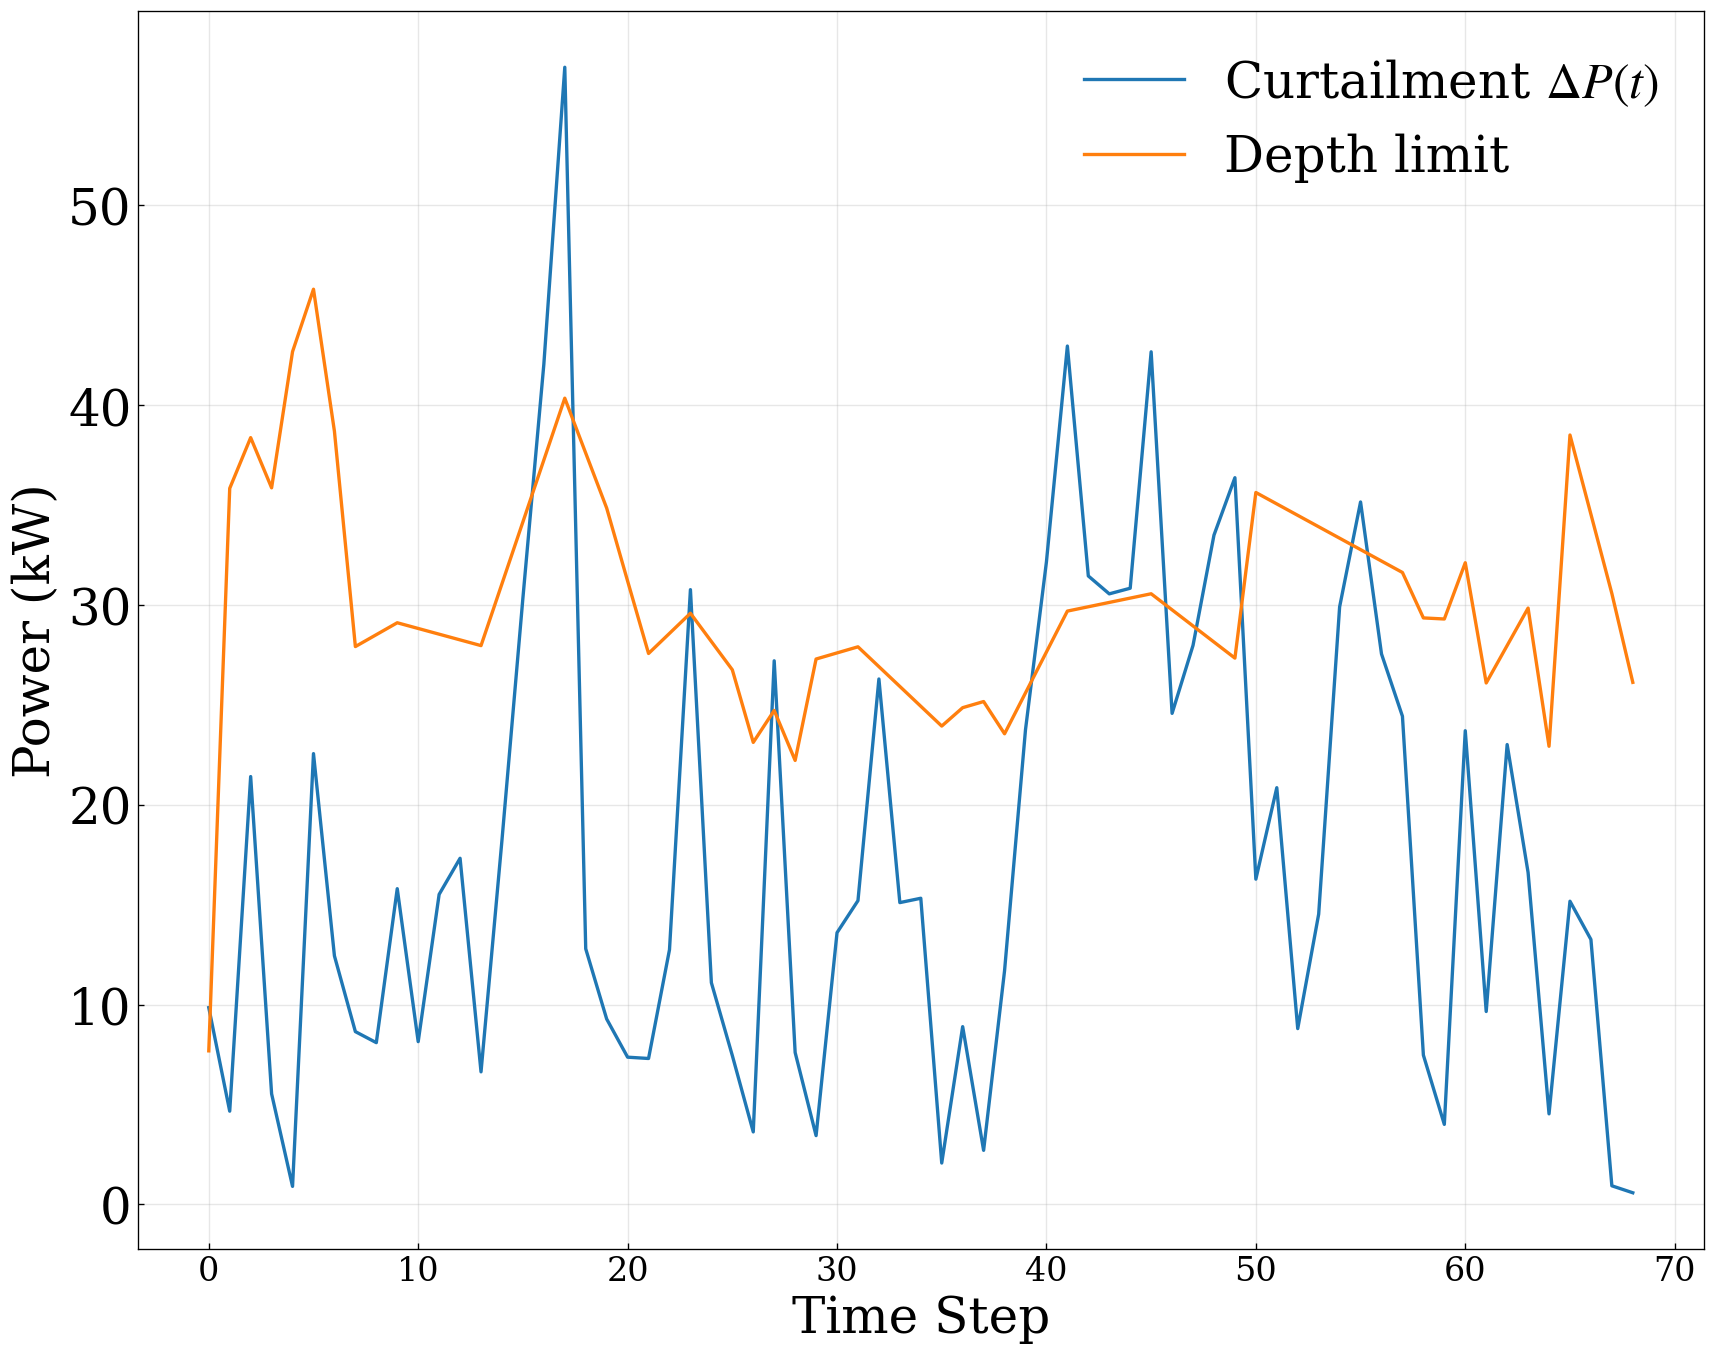

In [38]:
plt.figure(figsize=(15, 12))
plt.plot(best_res['p_curt'][best_res['p_curt'] > 1e-6]*S_base, label='Curtailment $\Delta P(t)$')
plt.plot(best_res['P']*rho*lhat[best_res['p_curt']*S_base > 1e-6]*S_base, label='Depth limit')
plt.ylabel("Power (kW)")
plt.xlabel("Time Step")
plt.legend()

C:\Users\gcsar\AppData\Local\Temp\ipykernel_12480\4284768025.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


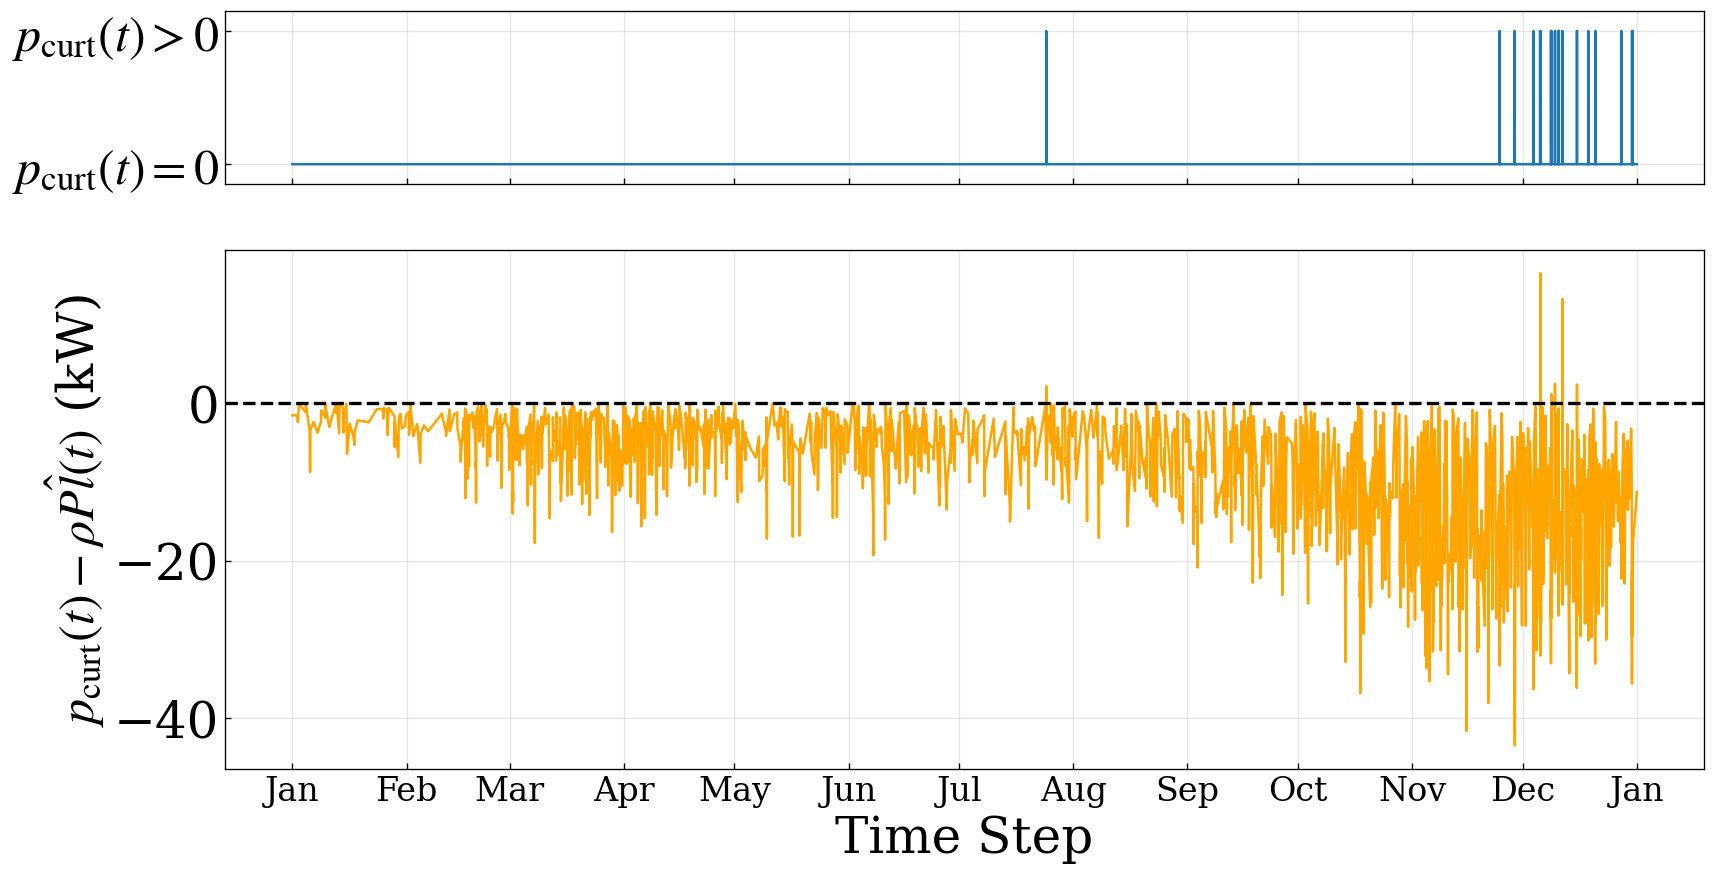

In [40]:
## Checking where curtailment exceeds the depth limit in terms of whole planning horizon

time_index = pd.date_range(
    start="2007-01-01",
    end="2008-01-01",
    freq="15min",
    inclusive="left"
)

# ===== Data =====
p_curt_kw = best_res['p_curt'] * S_base
limit = rho * best_res['P'] * lhat * S_base
gap = p_curt_kw - limit
mask = p_curt_kw > 1e-6
violation_mask = gap > 0

# ===== Figure =====
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# --- Top: Intervention timeline ---
ax1.step(time_index, mask.astype(int), where="mid", linewidth=1.5)
ax1.set_yticks([0, 1])
ax1.set_yticklabels([r"$p_{\mathrm{curt}}(t)=0$", r"$p_{\mathrm{curt}}(t)>0$"])
ax1.set_ylim(-0.15, 1.15)
ax1.grid(alpha=0.3)

# --- Bottom: normal continuous plot ---
ax2.plot(
    time_index, gap,
    linewidth=1.5,
    color="orange",
    # label=r"$p_{\mathrm{curt}}(t)-\rho P\hat{l}(t)$"
)

ax2.axhline(0, linestyle="--", linewidth=2, color="black")

ax2.set_ylabel(r"$p_{\mathrm{curt}}(t)-\rho P\hat{l}(t)$ (kW)")
ax2.legend()
ax2.grid(alpha=0.3)

# ===== Month formatting =====
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.set_xlabel("Time Step")

plt.tight_layout()
plt.show()

### CVaR CDF

In [41]:

def cvar_cdf(res, lhat, rho, alpha=0.99):
    P = res["P"]
    p_curt = np.asarray(res["p_curt"]).flatten()

    z = p_curt - rho * P * lhat
    z_sorted = np.sort(z)
    T = len(z)

    cdf = np.arange(1, T + 1) / T

    # VaR and CVaR
    var_alpha = np.quantile(z, alpha)
    cvar_alpha = z[z >= var_alpha].mean()

    plt.figure(figsize=(15, 12))

    # CDF
    plt.plot(z_sorted, cdf, linewidth=2)

    # key vertical lines
    plt.axvline(0, linestyle="--", linewidth=2, label="0 (no violation)")
    plt.axvline(var_alpha, linestyle="--", linewidth=2, label=f"VaR ({alpha})")
    plt.axvline(cvar_alpha, linestyle="-", linewidth=2, label="CVaR")

    plt.xlabel(r"$\zeta(t)$")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(-0.01, 0.01)

    plt.tight_layout()
    plt.show()

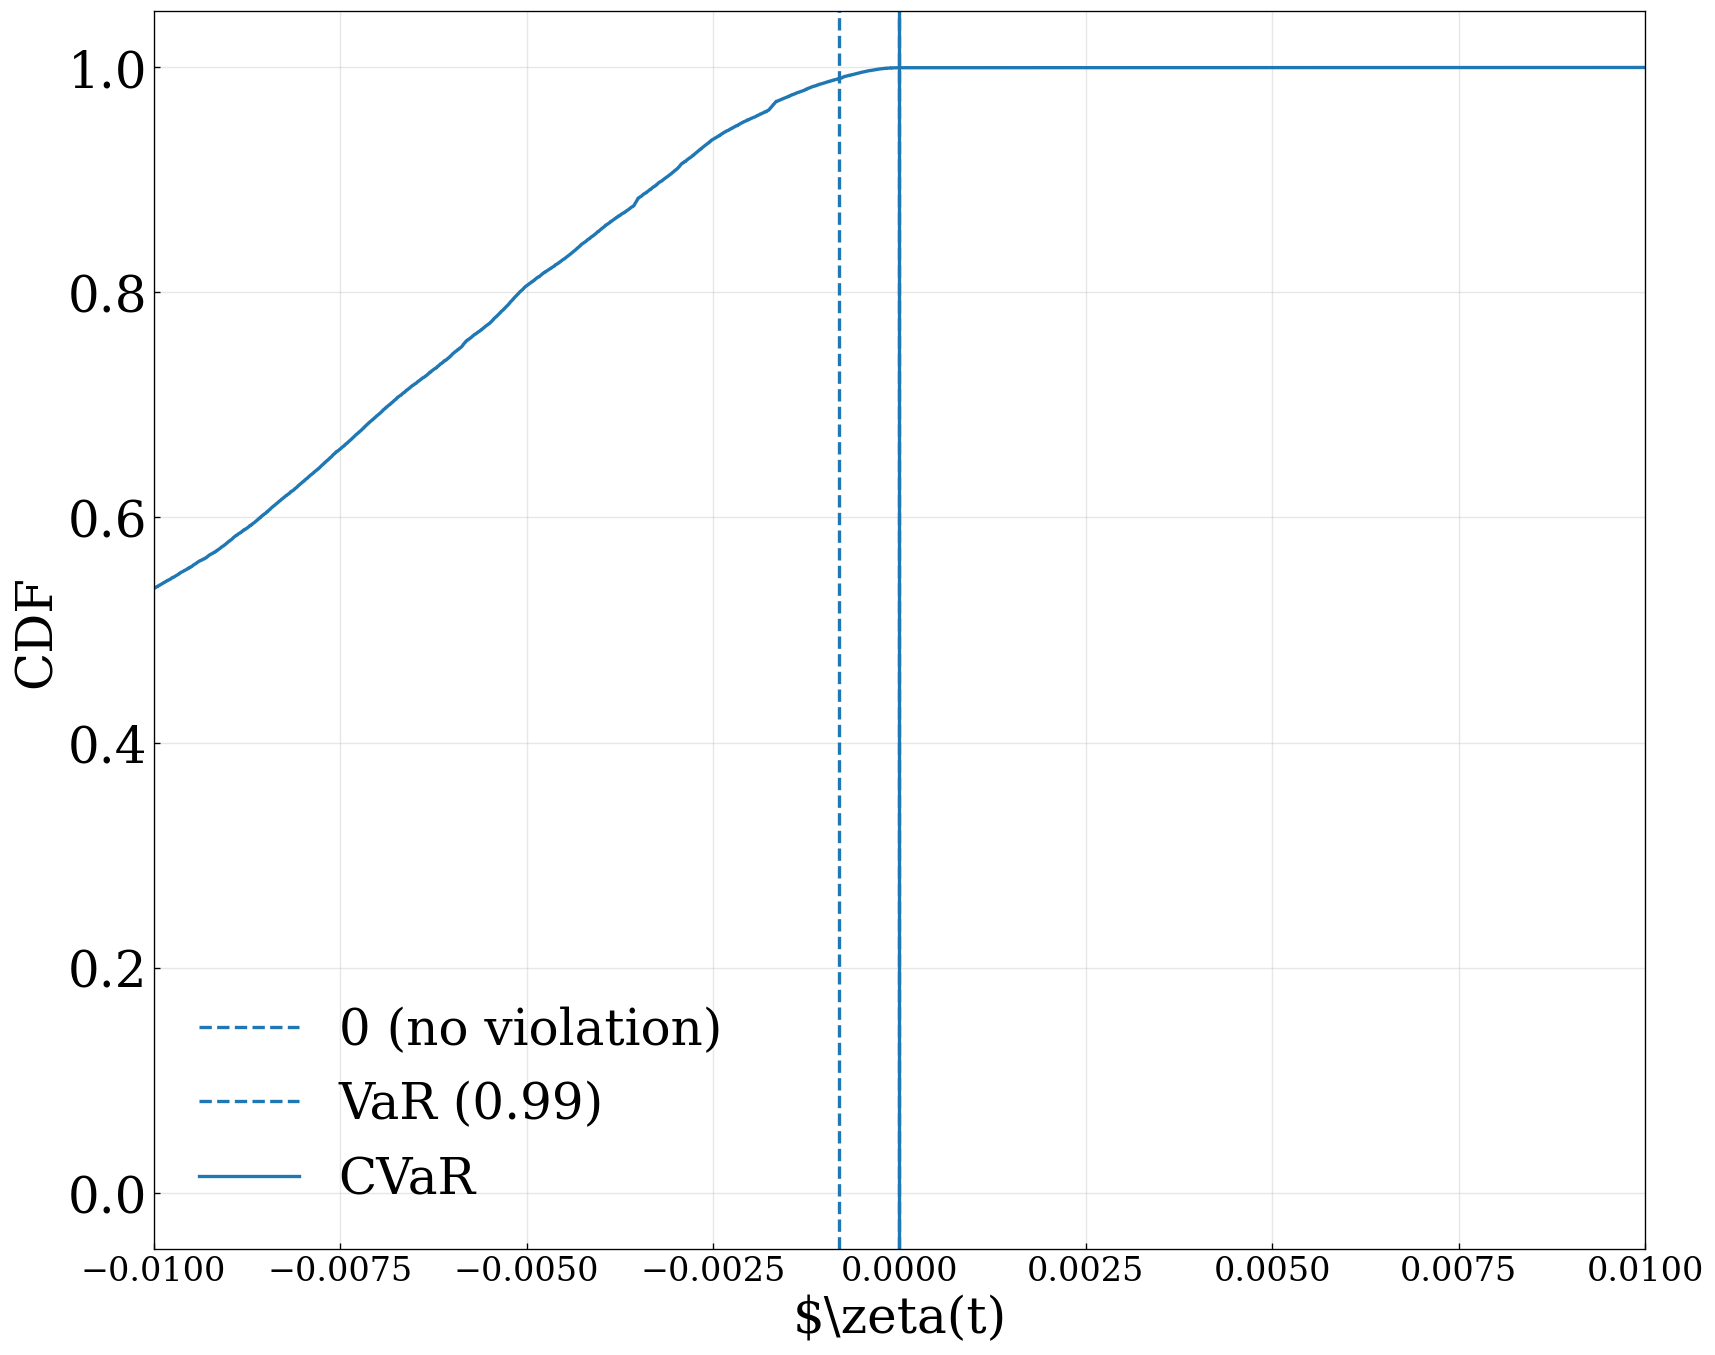

In [ ]:
# Commute 
cdf_info = cvar_cdf(best_res, lhat, rho=0.20, alpha=0.99)